# Ejercicio Integrador — Rating, Sentimiento y Perfil de Viajero
 
Una cadena de hoteles quiere entender qué hace que una estadía sea buena o mala, más allá del promedio de estrellas. Tienen 340 reseñas de sus hoteles, con el texto completo de cada reseña y datos de quién la escribió. Se pide un análisis que combine el rating, el texto y el perfil del viajero para producir conclusiones accionables.
 
## Dataset
 
`reviews_hoteles.csv` — 340 filas, 8 columnas:
 
| Columna | Descripción |
|---|---|
| `fecha` | Fecha de la reseña |
| `hotel` | Nombre del hotel |
| `ciudad` | Ciudad donde está el hotel |
| `categoria_hotel` | Categoría oficial del hotel, en estrellas (1 a 5, fija por hotel) |
| `rating_usuario` | Puntuación que el huésped le dio a su estadía (1 a 5) |
| `review` | Texto de la reseña |
| `motivo_viaje` | Negocios, Familia, Pareja, Amigos o Solo |
| `procedencia` | País de origen del huésped |

In [124]:
import pandas as pd

df = pd.read_csv("reviews_hoteles.csv")
df

,fecha,hotel,ciudad,categoria_hotel,rating_usuario,review,motivo_viaje,procedencia
0,2025-10-01,Hotel Costa Azul,Mar del Plata,3,3,"La habitación era correcta, el check-in tardó ...",Familia,Colombia
1,2025-10-01,Hotel Faro Viejo,Puerto Madryn,3,5,"El desayuno fue espectacular, variedad y muy b...",Familia,Chile
2,2025-10-01,Posada del Sol,Salta,3,1,Wifi prácticamente inexistente durante toda la...,Pareja,España
3,2025-10-03,Gran Hotel Andes,Bariloche,5,2,Wifi prácticamente inexistente durante toda la...,Pareja,Brasil
4,2025-10-03,Boutique Palermo Suites,Buenos Aires,4,4,"Excelente atención del personal, superó todas ...",Familia,México
...,...,...,...,...,...,...,...,...
335,2026-01-28,Hostal Las Termas,Termas de Río Hondo,2,4,"Excelente atención del personal, superó todas ...",Solo,Chile
336,2026-01-29,Gran Hotel Andes,Bariloche,5,4,"Habitación impecable, muy cómoda y con una vis...",Solo,Brasil
337,2026-01-30,Resort Laguna Azul,Villa Carlos Paz,5,1,Wifi prácticamente inexistente durante toda la...,Familia,Brasil
338,2026-01-30,Boutique Palermo Suites,Buenos Aires,4,4,"El desayuno fue espectacular, variedad y muy b...",Amigos,Colombia


## Consigna
 
1. **EDA sobre rating.** Explorar la distribución de `rating_usuario` y compararla contra `categoria_hotel`. ¿Los hoteles de más estrellas tienen, en promedio, mejor rating de usuario?

In [125]:
df[["rating_usuario", "categoria_hotel"]]

,rating_usuario,categoria_hotel
0,3,3
1,5,3
2,1,3
3,2,5
4,4,4
...,...,...
335,4,2
336,4,5
337,1,5
338,4,4


In [126]:
# Tu codigo acá
print("Promedio de categoria hotel: ", df["categoria_hotel"].mean())
print("Promedio de ratings de usuarios: ", df["rating_usuario"].mean())
print("----")

print(df["rating_usuario"].value_counts().sort_index())
print(df["categoria_hotel"].value_counts().sort_index())


Promedio de categoria hotel:  3.55
Promedio de ratings de usuarios:  3.45
----
rating_usuario
1     39
2     44
3     60
4    119
5     78
Name: count, dtype: int64
categoria_hotel
2     35
3    138
4    112
5     55
Name: count, dtype: int64


In [127]:
hoteles_1 = df[df["categoria_hotel"] == 1]
print("Rating promedio para los hoteles de categoría 1:", hoteles_1["rating_usuario"].mean())
hoteles_2 = df[df["categoria_hotel"] == 2]
print("Rating promedio para los hoteles de categoría 2:", hoteles_2["rating_usuario"].mean())
hoteles_3 = df[df["categoria_hotel"] == 3]
print("Rating promedio para los hoteles de categoría 3:", hoteles_3["rating_usuario"].mean())
hoteles_4 = df[df["categoria_hotel"] == 4]
print("Rating promedio para los hoteles de categoría 4:", hoteles_4["rating_usuario"].mean())
hoteles_5 = df[df["categoria_hotel"] == 5]
print("Rating promedio para los hoteles de categoría 5:", hoteles_5["rating_usuario"].mean())


Rating promedio para los hoteles de categoría 1: nan
Rating promedio para los hoteles de categoría 2: 3.6285714285714286
Rating promedio para los hoteles de categoría 3: 3.4565217391304346
Rating promedio para los hoteles de categoría 4: 3.4464285714285716
Rating promedio para los hoteles de categoría 5: 3.327272727272727


2. **Análisis de sentimiento.** Usar una herramienta de NLP ya entrenada para español (no entrenar ningún modelo propio) para clasificar cada `review` como positiva, negativa o neutra.

In [128]:
# Tu codigo acá
%pip install pysentimiento


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [129]:
from pysentimiento import create_analyzer

analyzer = create_analyzer(task="sentiment", lang="es")

def obtener_sentimiento(texto):
    # Validamos que no haya nulos
    if pd.isna(texto) or str(texto).strip() == "":
        return 'Neutra'
    
    # El modelo hace la predicción
    prediccion = analyzer.predict(str(texto)).output
    
    diccionario_sentimientos = {
        'POS': 'Positiva',
        'NEG': 'Negativa',
        'NEU': 'Neutra'
    }
    
    return diccionario_sentimientos.get(prediccion, 'Neutra')

df['sentimiento'] = df['review'].apply(obtener_sentimiento)

print(df[['review', 'sentimiento']])

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9393.58it/s]


                                                review sentimiento
0    La habitación era correcta, el check-in tardó ...      Neutra
1    El desayuno fue espectacular, variedad y muy b...    Positiva
2    Wifi prácticamente inexistente durante toda la...    Negativa
3    Wifi prácticamente inexistente durante toda la...    Negativa
4    Excelente atención del personal, superó todas ...    Positiva
..                                                 ...         ...
335  Excelente atención del personal, superó todas ...    Positiva
336  Habitación impecable, muy cómoda y con una vis...    Positiva
337  Wifi prácticamente inexistente durante toda la...    Negativa
338  El desayuno fue espectacular, variedad y muy b...    Positiva
339  Excelente atención del personal, superó todas ...    Positiva

[340 rows x 2 columns]


3. **Rating vs. sentimiento.** Convertir `rating_usuario` a una categoría comparable con el sentimiento detectado, y encontrar los casos donde no coinciden. Calcular qué porcentaje de las reseñas cae en cada caso.

In [130]:
df["sentimiento_rating"] = df["rating_usuario"].map({
    1: "Negativa",
    2: "Negativa",
    3: "Neutra",
    4: "Positiva",
    5: "Positiva"
})

print("Promedio por sentimiento en las reseñas de los usuarios: ", df["sentimiento_rating"].value_counts(normalize=True)*100)
print("Promedio por sentimiento en las reseñas de los usuarios obtenido por pysentimiento:" , df["sentimiento"].value_counts(normalize=True)*100)

Promedio por sentimiento en las reseñas de los usuarios:  sentimiento_rating
Positiva    57.941176
Negativa    24.411765
Neutra      17.647059
Name: proportion, dtype: float64
Promedio por sentimiento en las reseñas de los usuarios obtenido por pysentimiento: sentimiento
Positiva    61.764706
Negativa    21.470588
Neutra      16.764706
Name: proportion, dtype: float64


In [131]:
discrepancias = df[
    df["sentimiento_rating"] != df["rating_usuario"]
]

print(discrepancias[[
    "sentimiento",
    "rating_usuario",
    "sentimiento_rating",
    "review"
]])

    sentimiento  rating_usuario sentimiento_rating  \
0        Neutra               3             Neutra   
1      Positiva               5           Positiva   
2      Negativa               1           Negativa   
3      Negativa               2           Negativa   
4      Positiva               4           Positiva   
..          ...             ...                ...   
335    Positiva               4           Positiva   
336    Positiva               4           Positiva   
337    Negativa               1           Negativa   
338    Positiva               4           Positiva   
339    Positiva               5           Positiva   

                                                review  
0    La habitación era correcta, el check-in tardó ...  
1    El desayuno fue espectacular, variedad y muy b...  
2    Wifi prácticamente inexistente durante toda la...  
3    Wifi prácticamente inexistente durante toda la...  
4    Excelente atención del personal, superó todas ...  
..       

4. **Segmentación por perfil.** Comparar rating y sentimiento según `motivo_viaje` y `procedencia`. ¿Hay diferencias entre cómo puntúan los viajeros de negocios y los de ocio?

In [132]:
rating_por_motivo = (
    df.groupby("motivo_viaje")["rating_usuario"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

print(rating_por_motivo)

df["tipo_viaje"] = df["motivo_viaje"].apply(
    lambda x: "Negocios" if x == "Negocios" else "Ocio"
)

df.groupby("tipo_viaje")["rating_usuario"].agg(
    ["count", "mean", "median", "std"]
).round(2)

              count  mean  median   std
motivo_viaje                           
Amigos           67  3.31     3.0  1.17
Familia          80  3.51     4.0  1.30
Negocios         65  3.46     4.0  1.39
Pareja           48  3.52     4.0  1.35
Solo             80  3.45     4.0  1.26


,count,mean,median,std
tipo_viaje,,,,
Negocios,65,3.46,4.0,1.39
Ocio,275,3.45,4.0,1.26


In [133]:
pd.crosstab(
    df["tipo_viaje"],
    df["sentimiento_rating"],
    normalize="index"
).round(3) * 100

sentimiento_rating,Negativa,Neutra,Positiva
tipo_viaje,,,
Negocios,26.2,12.3,61.5
Ocio,24.0,18.9,57.1


In [134]:
rating_por_pais = (
    df.groupby("procedencia")["rating_usuario"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)
df.groupby("procedencia")["rating_usuario"].agg(
    ["count", "mean", "median", "std"]
).round(2)

pd.crosstab(
    df["procedencia"],
    df["sentimiento_rating"],
    normalize="index"
).round(3) * 100

sentimiento_rating,Negativa,Neutra,Positiva
procedencia,,,
Argentina,23.7,13.6,62.7
Brasil,32.8,17.2,50.0
Chile,36.2,10.6,53.2
Colombia,26.5,10.2,63.3
España,17.4,21.7,60.9
México,8.3,27.1,64.6
Uruguay,24.2,27.3,48.5


5. **Brecha categoría-experiencia.** Por hotel, calcular la diferencia entre `categoria_hotel` y el `rating_usuario` promedio. Identificar los hoteles con mayor brecha negativa.

In [135]:
# Tu codigo acá

6. **Visualización.** Al menos dos gráficos: uno que cruce rating y sentimiento, y otro que compare sentimiento entre segmentos de viajero.

sentimiento     Negativa  Neutra  Positiva
rating_usuario                            
1                     33       4         2
2                     34       6         4
3                      0      45        15
4                      4       0       115
5                      2       2        74


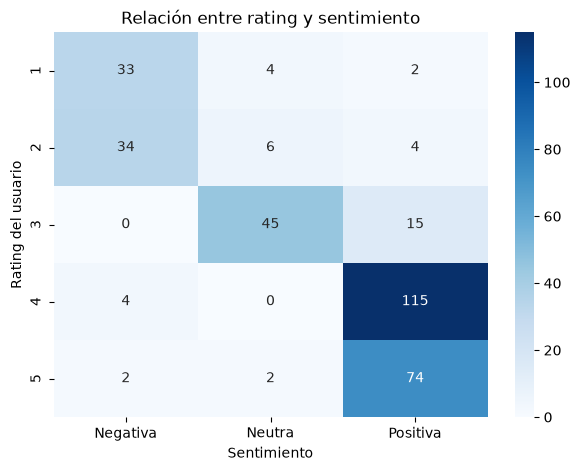

In [136]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

tabla = pd.crosstab(
    df["rating_usuario"],
    df["sentimiento"]
)

print(tabla)

plt.figure(figsize=(7, 5))

sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Relación entre rating y sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Rating del usuario")
plt.show()

sentimiento    Negativa     Neutra   Positiva
motivo_viaje                                 
Amigos        25.373134  20.895522  53.731343
Familia       21.250000  13.750000  65.000000
Negocios      20.000000  15.384615  64.615385
Pareja        20.833333  16.666667  62.500000
Solo          20.000000  17.500000  62.500000


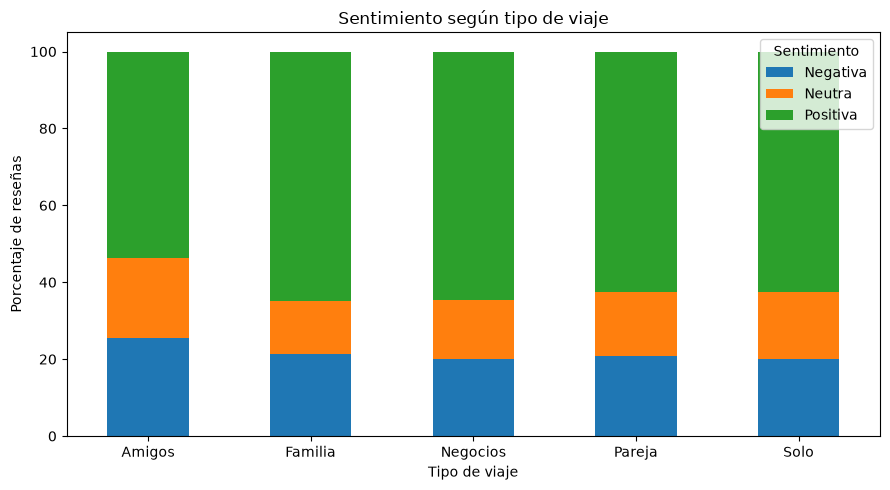

In [137]:
tabla = pd.crosstab(
    df["motivo_viaje"],
    df["sentimiento"],
    normalize="index"
) * 100

print(tabla)

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Sentimiento según tipo de viaje")
plt.xlabel("Tipo de viaje")
plt.ylabel("Porcentaje de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")

plt.tight_layout()
plt.show()

sentimiento   Negativa     Neutra   Positiva
tipo_viaje                                  
Negocios     20.000000  15.384615  64.615385
Ocio         21.818182  17.090909  61.090909


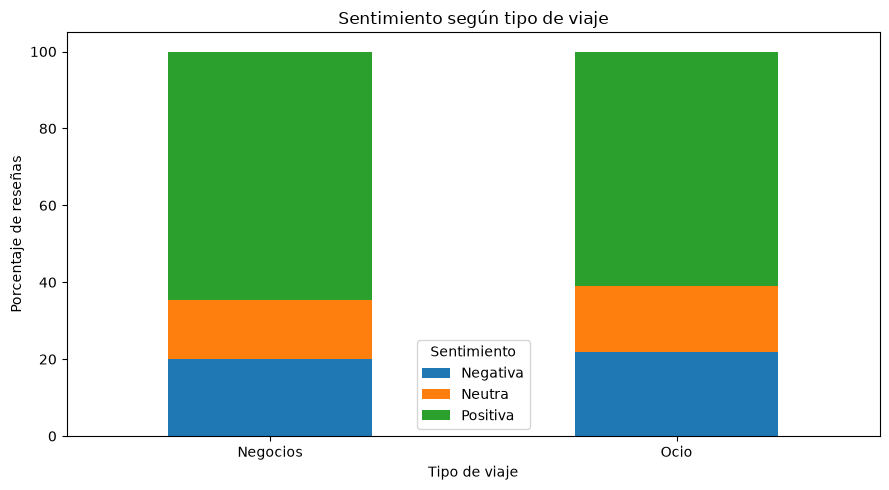

In [138]:
tabla = pd.crosstab(
    df["tipo_viaje"],
    df["sentimiento"],
    normalize="index"
) * 100

print(tabla)

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Sentimiento según tipo de viaje")
plt.xlabel("Tipo de viaje")
plt.ylabel("Porcentaje de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")

plt.tight_layout()
plt.show()

7. **Storytelling.** Con los resultados anteriores, escribir una conclusión de negocio de 3 a 5 oraciones dirigida a la cadena de hoteles. Debe basarse en los números encontrados, no en impresiones generales.

In [139]:
# Tu codigo acá

## Pistas
 
- Para el análisis de sentimiento, `pysentimiento` es una librería en Python con un modelo ya entrenado para español — no hace falta entrenar nada, se instala y se usa directo.
- `categoria_hotel` y `rating_usuario` son cosas distintas: una es fija por hotel, la otra varía por reseña. La consigna 5 depende de no confundirlas.
- Para "no coincide" en la consigna 3, primero hay que llevar el rating a la misma escala que devuelve el modelo de sentimiento (positivo / negativo / neutro).
- Conviene resolver la consigna 1 antes que la 2 — tener una idea de cómo se distribuye el rating ayuda a interpretar mejor los resultados del sentimiento después.